# Learning Seaborn (coming from Matplotlib)

You already know matplotlib, so this notebook skips the basics and focuses on
**what seaborn actually adds on top of matplotlib**. Each section is a concept,
with a working example on the e-commerce dataset, followed by a short
**"Try it yourself"** exercise (marked `# TODO`).

Seaborn is built on matplotlib. Every seaborn plot is still a matplotlib `Figure`/`Axes`
under the hood — seaborn just changes *how you describe* the plot and *what it computes for
you* (aggregation, confidence intervals, color mapping, faceting).

**Topics covered:**
1. The core mental shift: long-form data + `data=`, `x=`, `y=`, `hue=`
2. Styling the seaborn way (`set_theme`, `palette`, `despine`) instead of manual matplotlib styling
3. Relational plots: `scatterplot`, `lineplot`, `relplot` (+ faceting with `col=`/`row=`)
4. Categorical plots: `barplot`, `boxplot`, `violinplot`, `stripplot`, `catplot`
5. Distribution plots: `histplot`, `kdeplot`, `displot`
6. Matrix plots: `heatmap`, `pairplot`
7. Regression plots: `regplot`, `lmplot`
8. Building a fully custom themed dashboard using seaborn's own styling tools
9. Practice exercises


## 0. Setup

If you have your own `data/ecommerce_sales.csv` (same columns as before), it will be used.
Otherwise this generates synthetic data with the same schema so every cell below still runs.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("ecommerce_sales.csv")


df["order_date"] = pd.to_datetime(df["order_date"])
df["month"] = df["order_date"].dt.month_name()
df["month"] = pd.Categorical(
    df["month"],
    categories=["January","February","March","April","May","June",
                "July","August","September","October","November","December"],
    ordered=True,
)

df.head()


,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,month
0,10001,2022-01-01,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20,January
1,10002,2022-01-02,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10,January
2,10003,2022-01-03,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35,January
3,10004,2022-01-04,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90,January
4,10005,2022-01-05,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56,January


## 1. The core mental shift: long-form data

**Matplotlib mindset:** pull out arrays yourself, plot arrays.
```python
plt.scatter(df["discount"], df["revenue"])
```

**Seaborn mindset:** hand seaborn the whole dataframe, then just *name the columns*.
This becomes powerful once you add `hue`, `size`, or `style` — seaborn handles the
color mapping and legend automatically, something that takes several manual lines in matplotlib.

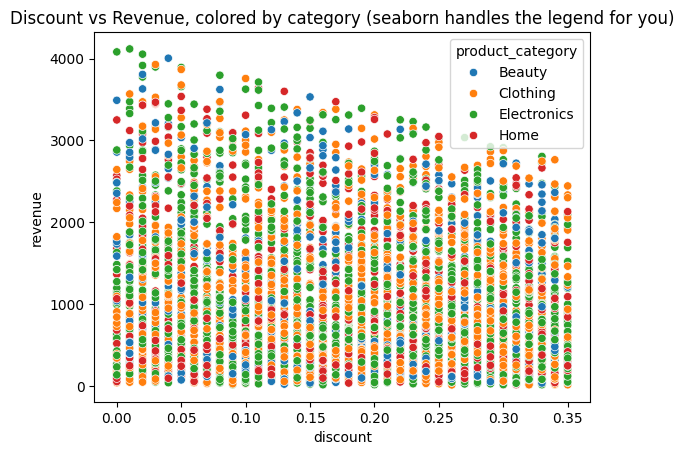

In [3]:
# Matplotlib way: you would need a manual loop over categories to color by product_category
# Seaborn way: just map the column to `hue`
#hue means color by category, and seaborn will automatically handle the legend for you
sns.scatterplot(data=df, x="discount", y="revenue", hue="product_category")
plt.title("Discount vs Revenue, colored by category (seaborn handles the legend for you)")
plt.show()


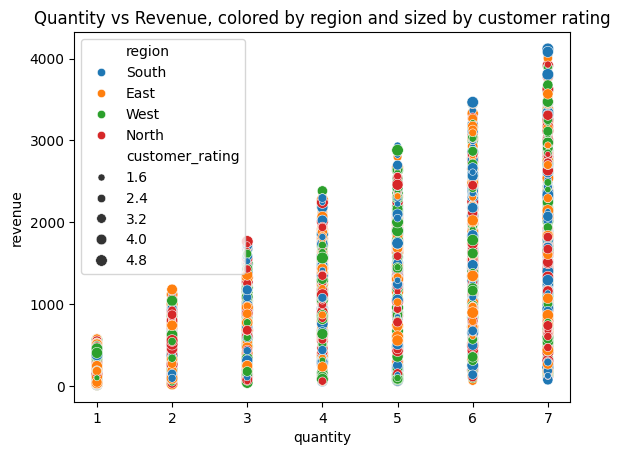

In [4]:
# TODO: Try it yourself
# Make a scatterplot of "quantity" vs "revenue", colored (hue) by "region",
# and sized (size) by "customer_rating".
# Hint: sns.scatterplot(data=df, x=..., y=..., hue=..., size=...)
sns.scatterplot(data=df,x='quantity',y='revenue',hue='region',size='customer_rating')
plt.title("Quantity vs Revenue, colored by region and sized by customer rating")
plt.show()


## 2. Styling the seaborn way

Instead of manually setting `facecolor`, `tick_params`, etc. on every plot (the matplotlib way),
seaborn gives you global styling functions you set **once** at the top of your notebook:

- `sns.set_theme(style=..., palette=..., font_scale=...)` — sets everything at once
- `sns.set_style()` — just the background/grid (`"darkgrid"`, `"whitegrid"`, `"dark"`, `"white"`, `"ticks"`)
- `sns.set_palette()` — default color palette for all subsequent plots
- `sns.despine()` — removes top/right spines cleanly, no manual `ax.spines[...]` needed

Run each theme below and see how *every* plot after it changes, with zero per-plot styling code.

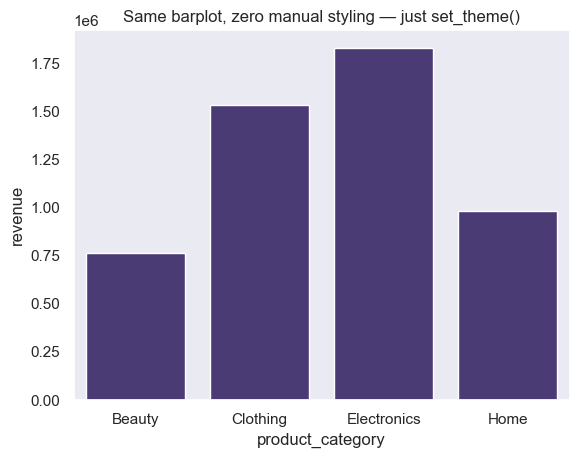

In [5]:
sns.set_theme(style="dark", palette="viridis")

sns.barplot(data=df, x="product_category", y="revenue", estimator="sum", errorbar=None)
plt.title("Same barplot, zero manual styling — just set_theme()")
plt.show()


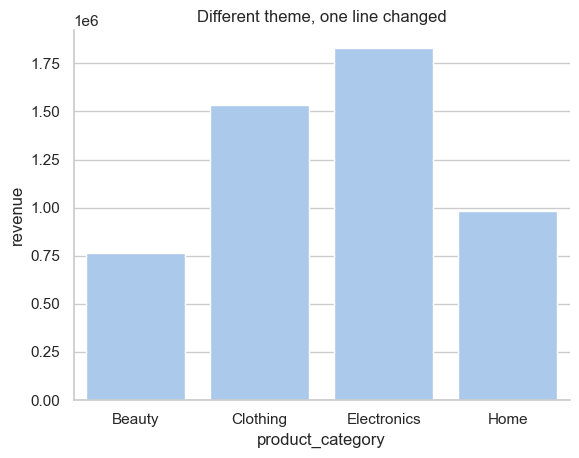

In [6]:
sns.set_theme(style="whitegrid", palette="pastel")

sns.barplot(data=df, x="product_category", y="revenue", estimator="sum", errorbar=None)
sns.despine()  # removes top/right border
plt.title("Different theme, one line changed")
plt.show()


<Axes: xlabel='product_category', ylabel='revenue'>

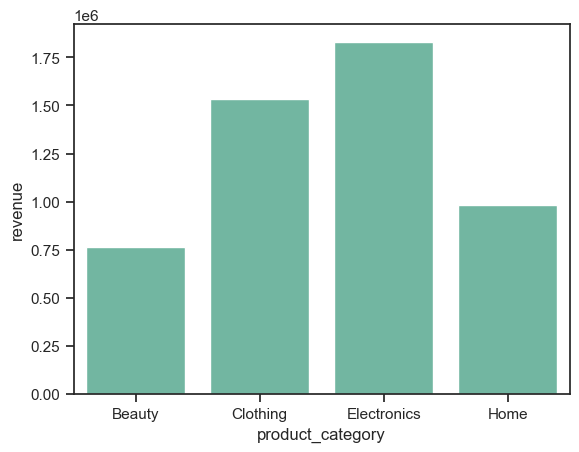

In [7]:
# TODO: Try it yourself
# Switch the theme to style="ticks", palette="Set2" and redraw the same barplot.
sns.set_theme(style='ticks', palette='Set2')
sns.barplot(data=df,x='product_category',y='revenue',estimator='sum',errorbar=None)


## 3. Relational plots: `scatterplot`, `lineplot`, `relplot`

`scatterplot` and `lineplot` are **axes-level** functions (like matplotlib — they draw on one `ax`).

`relplot` is a **figure-level** function: it can create a whole grid of small multiples
(facets) automatically using `col=` and/or `row=` — this is something matplotlib has no
shortcut for; you'd normally write a manual `plt.subplots()` loop.

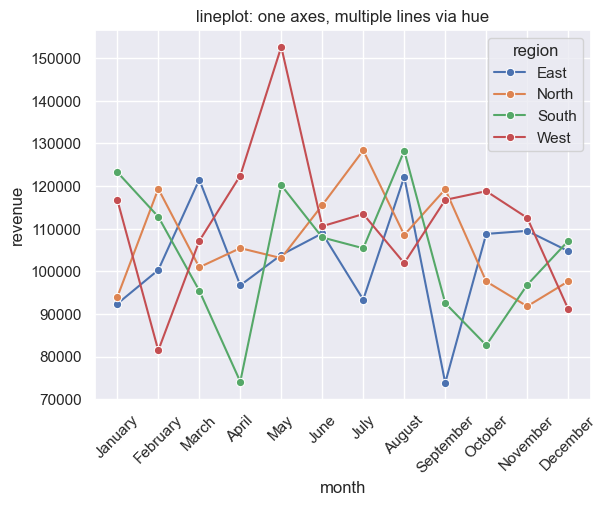

In [8]:
sns.set_theme(style="darkgrid")

monthly = df.groupby(["month", "region"], observed=True)["revenue"].sum().reset_index()

sns.lineplot(data=monthly, x="month", y="revenue", hue="region", marker="o")
plt.xticks(rotation=45)
plt.title("lineplot: one axes, multiple lines via hue")
plt.show()


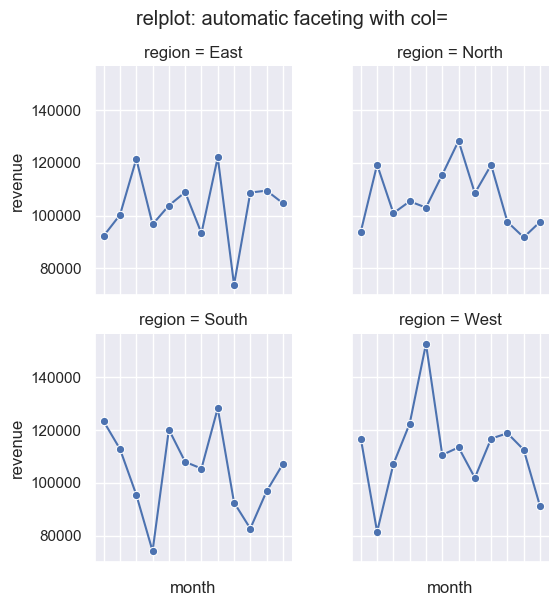

In [9]:
# relplot: same data, but faceted into a separate small chart per region.
# This single line replaces a manual plt.subplots(1, 4) loop.
g = sns.relplot(
    data=monthly, x="month", y="revenue",
    col="region", kind="line", marker="o", col_wrap=2, height=3
)
g.set_xticklabels(rotation=45)
g.fig.suptitle("relplot: automatic faceting with col=", y=1.03)
plt.show()


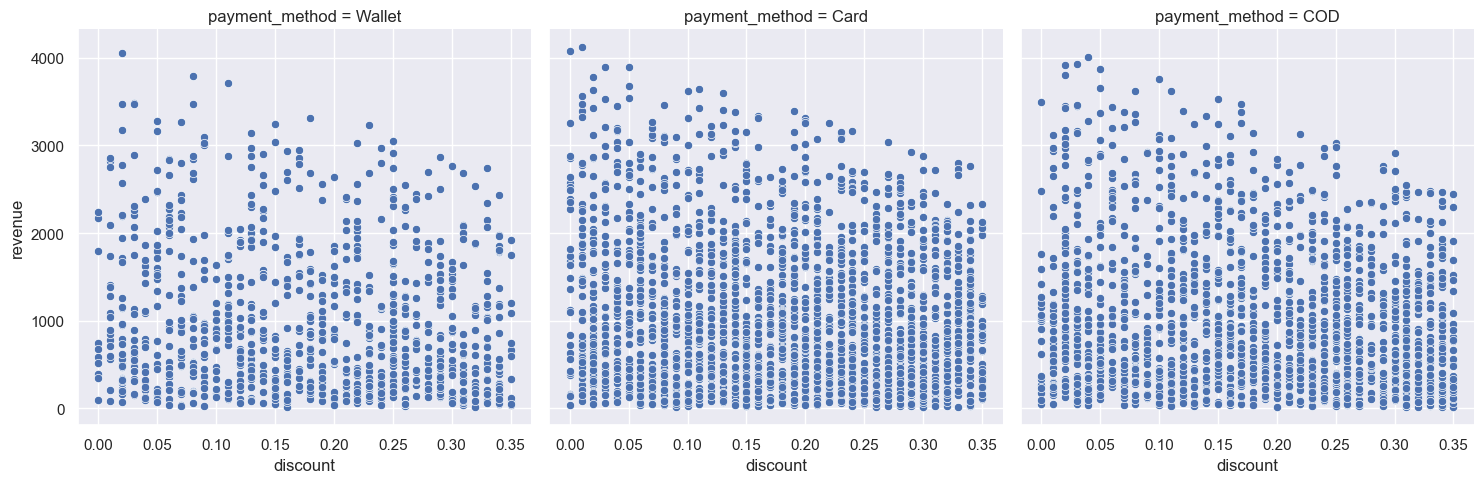

In [10]:
# TODO: Try it yourself
# Use relplot with kind="scatter" to plot "discount" vs "revenue",
# faceted by "payment_method" (col="payment_method").
sns.relplot(data=df,x='discount',y='revenue',col='payment_method',kind='scatter')



## 4. Categorical plots: `barplot`, `boxplot`, `violinplot`, `stripplot`, `catplot`

Seaborn's categorical plots do the **aggregation for you**. Compare:

- Matplotlib: `df.groupby("product_category")["revenue"].mean()` then `plt.bar(...)`
- Seaborn: `sns.barplot(data=df, x="product_category", y="revenue")` — the mean + confidence
  interval error bars are computed automatically.

`catplot` is the figure-level version (like `relplot`, but for categorical plots) — it can
switch its underlying plot type with `kind="bar"/"box"/"violin"/"strip"/"swarm"` and facet
with `col=`/`row=`.

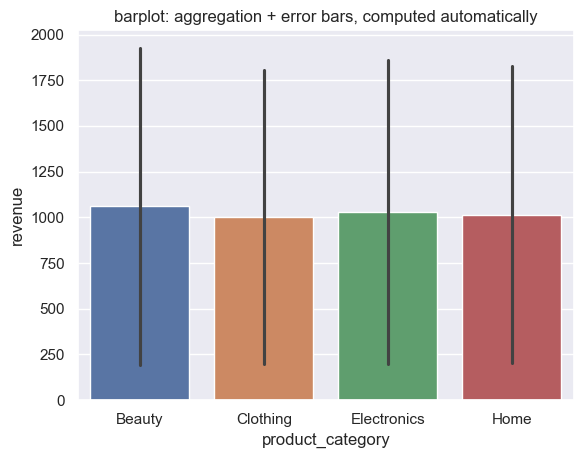

In [11]:
# No manual groupby needed — sns.barplot aggregates (mean by default) and adds error bars
sns.barplot(data=df, x="product_category", y="revenue", hue="product_category",
            legend=False, errorbar="sd")
plt.title("barplot: aggregation + error bars, computed automatically")
plt.show()


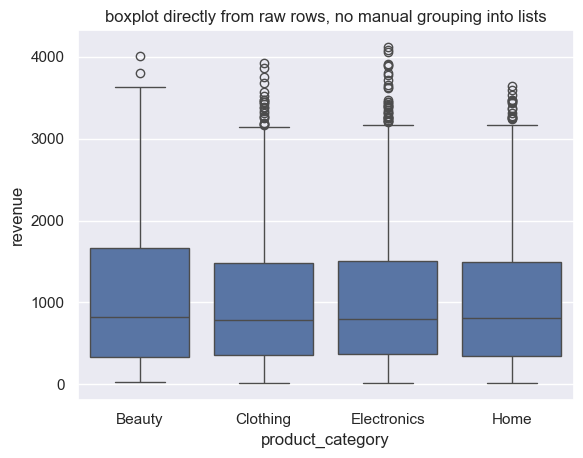

In [12]:
sns.boxplot(data=df, x="product_category", y="revenue")
plt.title("boxplot directly from raw rows, no manual grouping into lists")
plt.show()


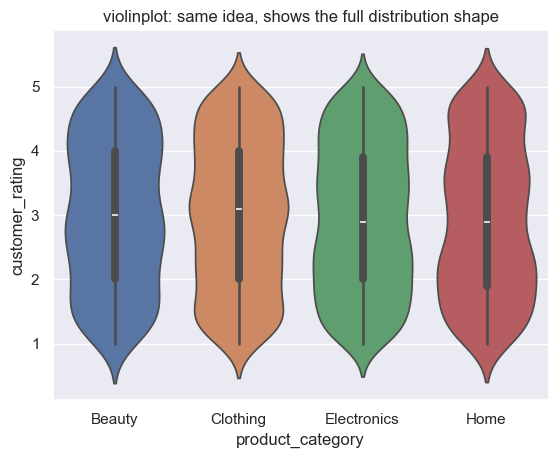

In [13]:
sns.violinplot(data=df, x="product_category", y="customer_rating", hue="product_category",
               legend=False)
plt.title("violinplot: same idea, shows the full distribution shape")
plt.show()


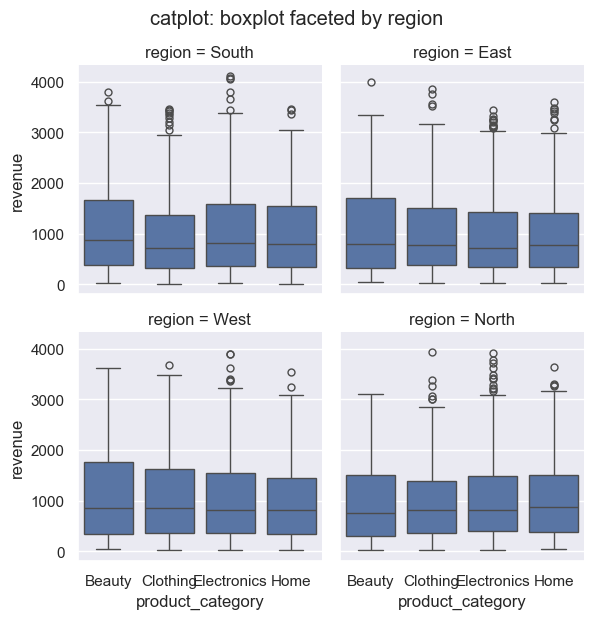

In [14]:
# catplot: figure-level, one line to facet a categorical plot by another column
g = sns.catplot(
    data=df, x="product_category", y="revenue",
    col="region", kind="box", col_wrap=2, height=3
)
g.fig.suptitle("catplot: boxplot faceted by region", y=1.03)
plt.show()


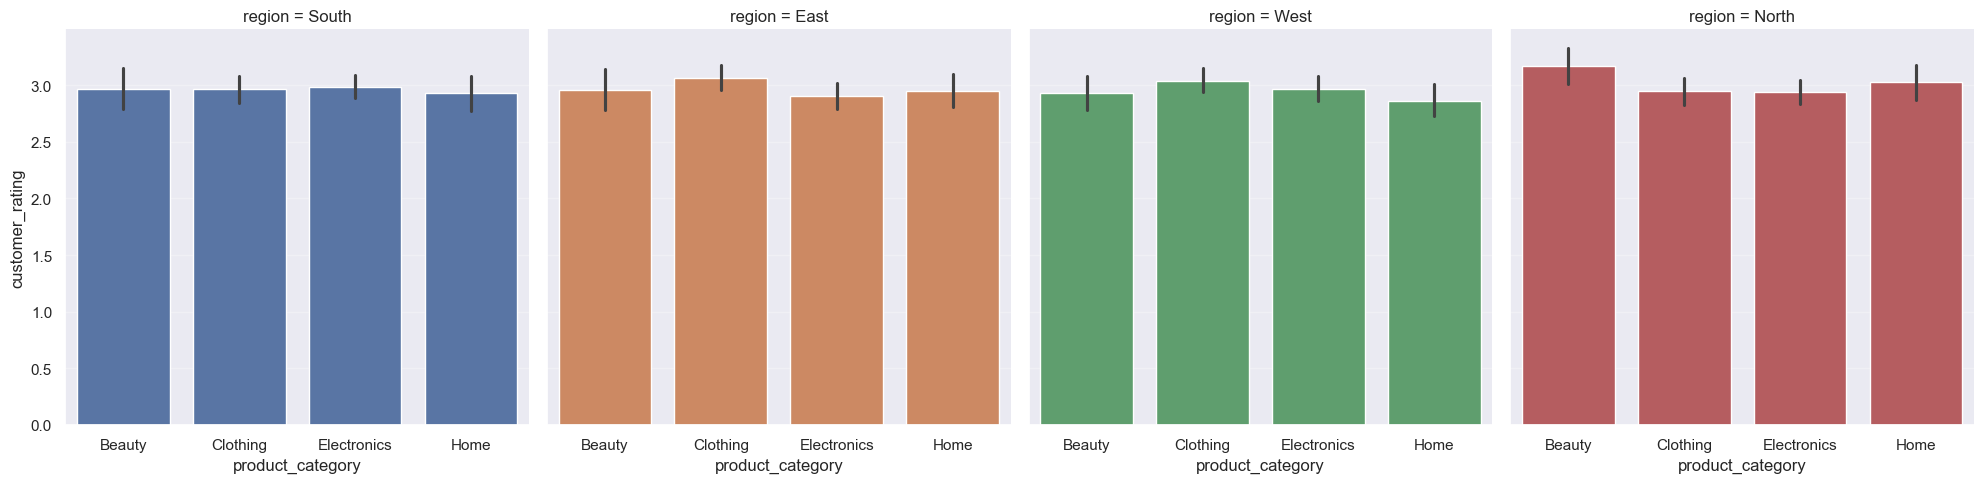

In [35]:
# TODO: Try it yourself
# Use sns.catplot with kind="bar" to show average "customer_rating" by "product_category",
# faceted by "region" (col="region").
sns.catplot(data=df,x='product_category',y='customer_rating',col='region',kind='bar',hue='region',legend=False)



## 5. Distribution plots: `histplot`, `kdeplot`, `displot`

`histplot` replaces `plt.hist`. `kdeplot` draws a smoothed density curve (no matplotlib
equivalent without scipy). Both support `hue` to compare distributions across groups on
one chart — try doing that in matplotlib and you'll see how many lines it normally takes.

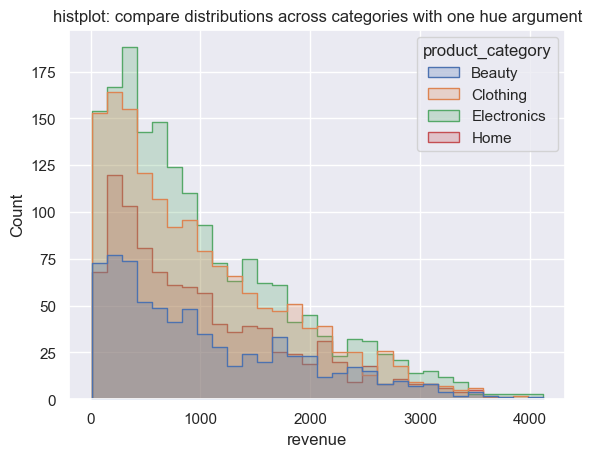

In [16]:
sns.histplot(data=df, x="revenue", hue="product_category", element="step", bins=30)
plt.title("histplot: compare distributions across categories with one hue argument")
plt.show()


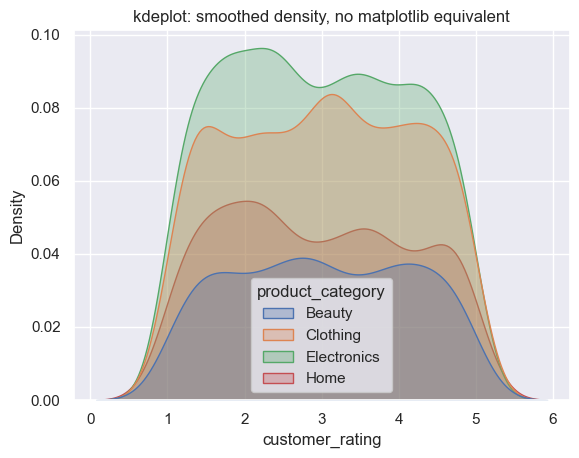

In [17]:
sns.kdeplot(data=df, x="customer_rating", hue="product_category", fill=True, alpha=0.3)
plt.title("kdeplot: smoothed density, no matplotlib equivalent")
plt.show()


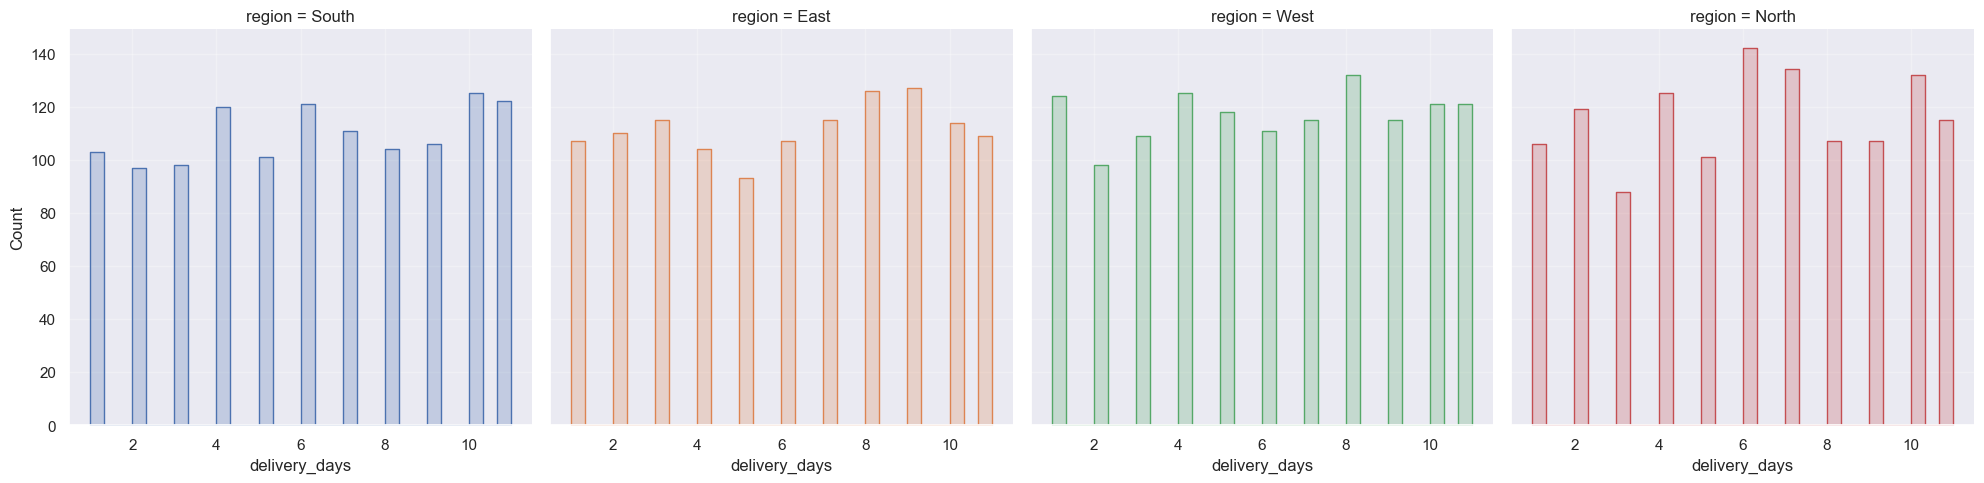

In [39]:
# TODO: Try it yourself
# Use sns.displot (figure-level) with kind="hist" to plot "delivery_days",
# faceted by "region" (col="region").
sns.displot(data=df,x='delivery_days',col='region',kind='hist',bins=30,element='step',hue='region',legend=False)



## 6. Matrix plots: `heatmap`, `pairplot`

`sns.heatmap` needs a 2D matrix (like a correlation matrix or pivot table) — it draws
the cells, colors, and annotations in one call instead of a manual `plt.imshow` + text loop.

`sns.pairplot` has **no real matplotlib equivalent** without a lot of manual subplot code:
it plots every numeric column against every other numeric column in a grid, with
histograms on the diagonal. Great for a first look at a new dataset.

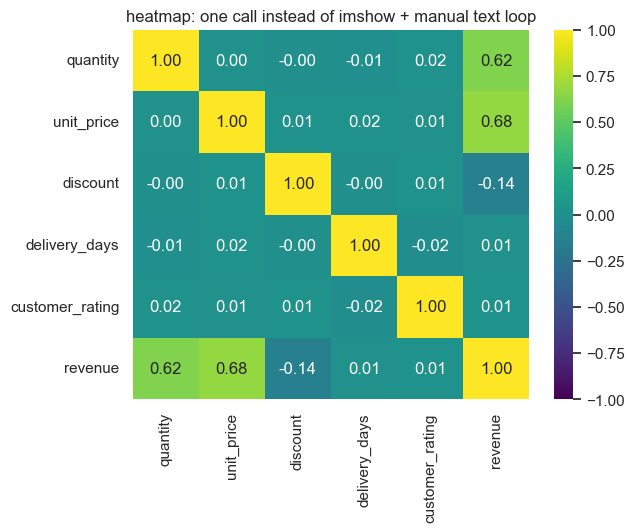

In [19]:
corr = df[["quantity", "unit_price", "discount", "delivery_days", "customer_rating", "revenue"]].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="viridis", vmin=-1, vmax=1)
plt.title("heatmap: one call instead of imshow + manual text loop")
plt.show()


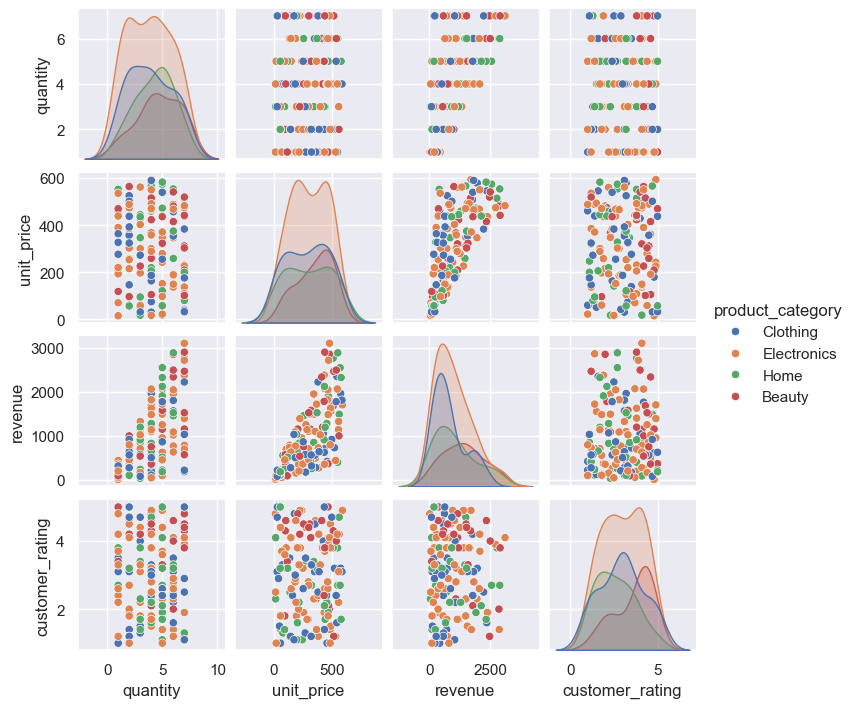

In [ ]:
# pairplot on a small sample for speed — this alone would take ~15 lines of matplotlib subplots
sample = df.sample(150, random_state=0)
sns.pairplot(sample[["quantity", "unit_price", "revenue", "customer_rating", "product_category"]],
             hue="product_category", height=1.8)
plt.show()

In [21]:
# TODO: Try it yourself
# Build a pivot table of average "revenue" by region (rows) and product_category (columns)
# using df.pivot_table(...), then plot it with sns.heatmap(..., annot=True).



## 7. Regression plots: `regplot`, `lmplot`

`sns.regplot` draws a scatterplot **and** fits/plots a regression line with a confidence
band in one call — in matplotlib you'd need `numpy.polyfit` plus manual line plotting.
`lmplot` is the figure-level version, so it can facet the regression by a categorical column.

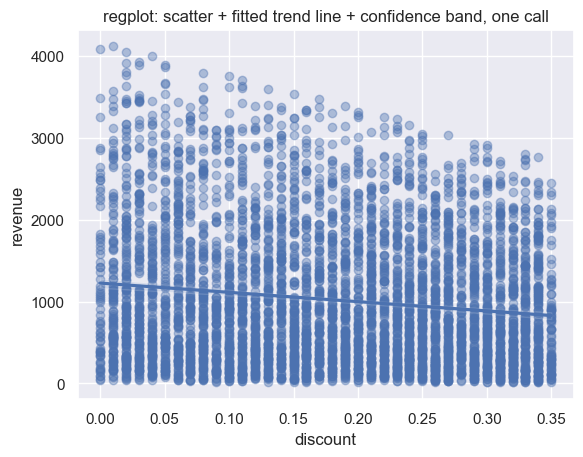

In [22]:
sns.regplot(data=df, x="discount", y="revenue", scatter_kws={"alpha": 0.4})
plt.title("regplot: scatter + fitted trend line + confidence band, one call")
plt.show()


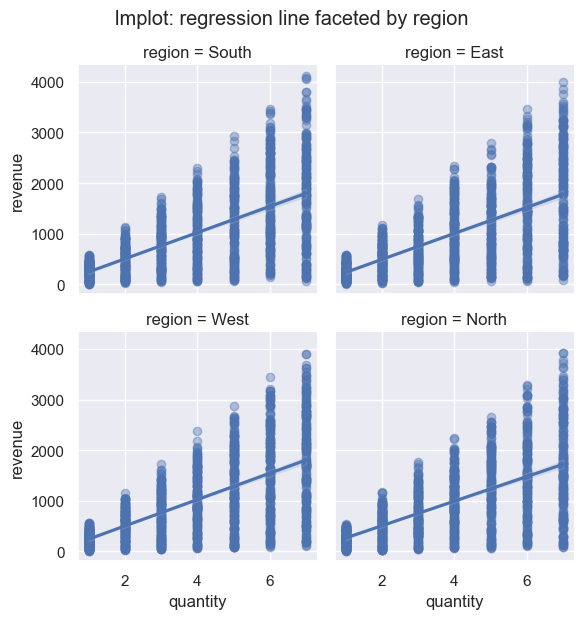

In [23]:
g = sns.lmplot(data=df, x="quantity", y="revenue", col="region", col_wrap=2, height=3,
               scatter_kws={"alpha": 0.4})
g.fig.suptitle("lmplot: regression line faceted by region", y=1.03)
plt.show()


In [24]:
# TODO: Try it yourself
# Use sns.lmplot to plot "unit_price" vs "revenue", with hue="product_category"
# (no faceting this time — hue puts everything on one plot with separate trend lines).



## 8. Building a fully custom theme (matching your original dark dashboard)

`sns.set_theme` accepts an `rc=` dict of matplotlib rcParams, so you *can* hit your exact
custom hex colors (`#1e1e1e` figure background, `#2b2b2b` axes background, cyan accents)
**without** manually calling `fig.patch.set_facecolor` / `tick_params` on every single plot,
like the original notebook did. Set it once, and every plot after inherits it.

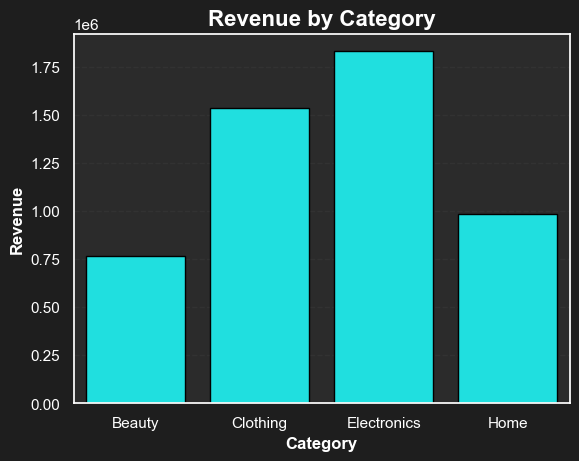

In [25]:
custom_dark = {
    "figure.facecolor": "#1e1e1e",
    "axes.facecolor": "#2b2b2b",
    "axes.edgecolor": "white",
    "axes.labelcolor": "white",
    "text.color": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "grid.color": "#444444",
    "grid.linestyle": "--",
    "grid.alpha": 0.3,
}
sns.set_theme(style="darkgrid", palette=["cyan"], rc=custom_dark)

sns.barplot(data=df, x="product_category", y="revenue", estimator="sum", errorbar=None,
            edgecolor="black")
plt.title("Revenue by Category", fontsize=16, fontweight="bold")
plt.xlabel("Category", fontsize=12, fontweight="bold")
plt.ylabel("Revenue", fontsize=12, fontweight="bold")
plt.show()

# Compare this cell to Cell 3 in your original matplotlib->seaborn conversion:
# there, fig.patch.set_facecolor / ax.set_facecolor / tick_params(colors="white") had
# to be repeated in every single cell. Here, set_theme(rc=...) was called ONCE above,
# and every plot for the rest of the notebook inherits the dark theme automatically.


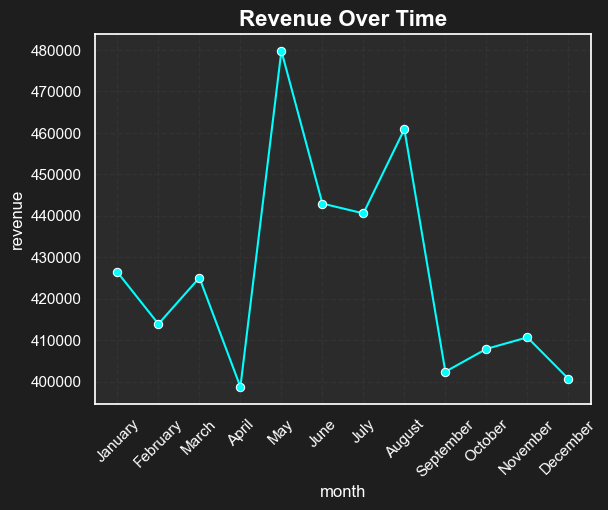

In [26]:
# This next plot needs zero styling code at all, since the theme is already active
sns.lineplot(data=df.groupby("month", observed=True)["revenue"].sum().reset_index(),
             x="month", y="revenue", marker="o", color="cyan")
plt.xticks(rotation=45)
plt.title("Revenue Over Time", fontsize=16, fontweight="bold")
plt.show()


In [27]:
# TODO: Try it yourself
# With the dark theme still active, plot a histplot of "revenue" (bins=30, color="cyan").
# Notice you do NOT need to set facecolor or tick_params manually.



In [28]:
# Reset back to seaborn's default theme when you're done with the custom one
sns.set_theme()


## 9. Practice exercises

Now combine everything above. Fill in each `# TODO` cell.

1. Set a theme of your choice with `sns.set_theme()`.
2. Build a `catplot` (`kind="bar"`) showing average `delivery_days` by `payment_method`,
   faceted by `region`.
3. Build a `heatmap` of the pivot table: average `customer_rating` by `region` (rows) and
   `product_category` (columns).
4. Build a `displot` (`kind="kde"`) of `revenue`, with `hue="payment_method"`.
5. Build an `lmplot` of `delivery_days` vs `customer_rating`, with `hue="region"`.

Try each one without looking back at the sections above — that's the fastest way for the
`data=`, `x=`, `y=`, `hue=` pattern to become automatic.

In [29]:
# 1. TODO



In [30]:
# 2. TODO



In [31]:
# 3. TODO



In [32]:
# 4. TODO



In [33]:
# 5. TODO



## Cheat sheet: matplotlib -> seaborn

| Matplotlib | Seaborn axes-level | Seaborn figure-level (faceting) |
|---|---|---|
| `plt.scatter(x, y)` | `sns.scatterplot(data=df, x=, y=, hue=)` | `sns.relplot(kind="scatter", col=/row=)` |
| `plt.plot(x, y)` | `sns.lineplot(data=df, x=, y=, hue=)` | `sns.relplot(kind="line", col=/row=)` |
| `plt.bar(x, y)` (after manual groupby) | `sns.barplot(data=df, x=, y=)` (auto-aggregates) | `sns.catplot(kind="bar", col=/row=)` |
| `plt.boxplot(groups, labels=...)` | `sns.boxplot(data=df, x=, y=)` (no manual grouping) | `sns.catplot(kind="box", col=/row=)` |
| `plt.violinplot(groups)` | `sns.violinplot(data=df, x=, y=)` | `sns.catplot(kind="violin", col=/row=)` |
| `plt.hist(x)` | `sns.histplot(data=df, x=, hue=)` | `sns.displot(kind="hist", col=/row=)` |
| n/a (needs scipy) | `sns.kdeplot(data=df, x=, hue=)` | `sns.displot(kind="kde", col=/row=)` |
| `plt.imshow(matrix)` + manual text loop | `sns.heatmap(matrix, annot=True)` | n/a |
| n/a (~15 lines of manual subplots) | n/a | `sns.pairplot(df, hue=)` |
| `np.polyfit` + `plt.plot` | `sns.regplot(data=df, x=, y=)` | `sns.lmplot(col=/row=, hue=)` |
| `plt.pie(...)` | **no seaborn equivalent** — stays matplotlib | — |
| stacked `plt.bar(..., bottom=...)` | **no seaborn equivalent** — stays matplotlib | — |
| `series.plot.area()` | **no seaborn equivalent** — stays matplotlib/pandas | — |
| manual `fig.patch.set_facecolor` etc. per plot | `sns.set_theme(style=, palette=, rc=)` once | — |
